In [1]:
import pandas as pd

In [6]:
d={"name":["Alice","Boberto"], "age":[25,30]}
df=pd.DataFrame(d) # to create a df strating form a dictionary

In [8]:
df= pd.read_csv("automobile_prices.csv")

In [10]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,ferrari,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,113495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
2,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
3,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
4,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950


In [12]:
df.info() #name of columns and how many not null values there are

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          206 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               206 non-null    str    
 3   fuel-type          206 non-null    str    
 4   aspiration         206 non-null    str    
 5   num-of-doors       204 non-null    str    
 6   body-style         206 non-null    str    
 7   drive-wheels       206 non-null    str    
 8   engine-location    206 non-null    str    
 9   wheel-base         206 non-null    float64
 10  length             206 non-null    float64
 11  width              206 non-null    float64
 12  height             206 non-null    float64
 13  curb-weight        206 non-null    int64  
 14  engine-type        206 non-null    str    
 15  num-of-cylinders   206 non-null    str    
 16  engine-size        206 non-null    in

In [23]:
df1=pd.read_csv("houses_to_rent_to_fix.csv")
df1.isnull()
df1.isnull().sum() #to sum all the boolean values, as True=1 and False=0
print(f"There are:\n {df1.isnull().sum()}")

There are:
 city                   0
area                   0
rooms                  4
bathroom               0
parking spaces         0
floor                  0
animal                 0
furniture              0
hoa (R$)               0
rent amount (R$)       0
property tax (R$)      0
fire insurance (R$)    0
total (R$)             0
dtype: int64


In [42]:
df1[df1["rooms"].isnull()] #check in df1, all the lines where the condition is matched
df1[(df1["bathroom"]>5)& (df1["rooms"]<6)]

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
15,Campinas,330,4.0,6,6,-,acept,furnished,680,8000,328,121,9129
40,São Paulo,300,4.0,6,4,20,acept,not furnished,3700,12000,1584,153,17440
131,São Paulo,900,4.0,6,8,-,acept,not furnished,0,15000,4417,226,19640
143,Campinas,999,5.0,7,8,-,acept,not furnished,0,14000,667,211,14880
180,São Paulo,384,4.0,6,4,3,not acept,furnished,3500,15000,344,191,19040
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10353,Campinas,437,3.0,6,6,-,acept,furnished,1200,13500,711,203,15610
10380,Campinas,800,4.0,7,4,-,acept,not furnished,2100,15000,1898,226,19220
10472,Campinas,900,3.0,6,8,-,acept,not furnished,2000,15000,1834,226,19060
10476,Porto Alegre,600,5.0,7,5,-,acept,not furnished,0,7000,834,125,7959


       city
rooms      
1.0    2453
2.0    2973
3.0    3269
4.0    1585
5.0     288
6.0      68
7.0      36
8.0      11
9.0       1
10.0      3
13.0      1


<Axes: xlabel='rooms'>

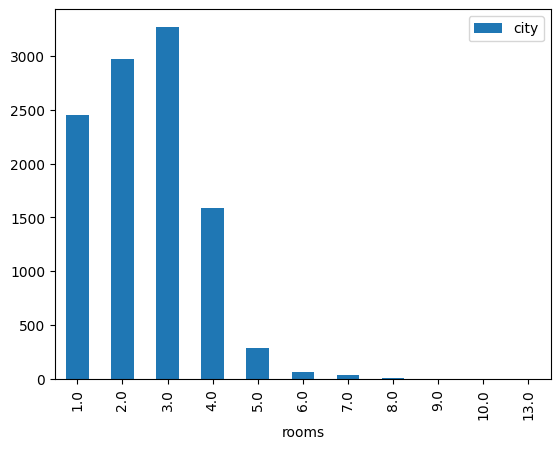

In [47]:
pivot= df1.pivot_table(index="rooms", #for each differnet value of index
                aggfunc= "count",  #use this function
                values="city") #on these values
print(pivot)
pivot.plot(kind="bar")

In [63]:
df1=df1[df1["total (R$)"]<1e4]
max_price=df1["total (R$)"].max()
print(f"The maximum price of the houses is {max_price}!")

The maximum price of the houses is 9998!


In [64]:
threshold=max_price*0.9
print(f"The threshold is {threshold}!")

The threshold is 8998.2!


In [65]:
top_df=df1[df1["total (R$)"]>threshold]
top_df

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
15,Campinas,330,4.0,6,6,-,acept,furnished,680,8000,328,121,9129
91,Porto Alegre,350,4.0,4,4,-,acept,furnished,1,9000,359,160,9520
109,Rio de Janeiro,309,4.0,5,4,7,acept,not furnished,2661,6500,682,84,9927
114,Belo Horizonte,133,4.0,4,3,6,not acept,not furnished,1500,7000,800,94,9394
127,São Paulo,217,3.0,4,3,1,acept,not furnished,2884,6500,0,83,9467
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10590,Belo Horizonte,350,5.0,2,7,-,acept,furnished,0,9000,602,148,9750
10645,Porto Alegre,400,4.0,2,2,15,acept,furnished,2250,6300,500,92,9142
10647,São Paulo,249,3.0,3,1,9,acept,furnished,2250,7000,420,89,9759
10664,Rio de Janeiro,310,3.0,2,0,5,not acept,not furnished,2500,6000,595,78,9173


In [66]:
top_df_sorted=top_df.sort_values(by="total (R$)", ascending=False)
top_df_sorted.head(20)

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
1130,São Paulo,360,4.0,9,8,-,acept,not furnished,0,8540,1329,129,9998
781,São Paulo,277,4.0,4,6,5,acept,not furnished,4200,3800,1947,49,9996
5781,São Paulo,208,3.0,3,2,2,acept,furnished,2354,7000,552,89,9995
1041,Belo Horizonte,800,7.0,7,4,-,acept,furnished,0,8900,943,146,9989
2059,São Paulo,375,4.0,5,3,-,acept,furnished,0,9000,850,136,9986
578,São Paulo,196,4.0,4,0,11,acept,not furnished,2450,6000,1458,77,9985
7695,São Paulo,190,3.0,2,1,6,acept,not furnished,3040,6800,56,87,9983
9875,São Paulo,160,3.0,2,1,5,acept,not furnished,1715,7700,470,98,9983
9212,Belo Horizonte,178,3.0,3,3,10,acept,not furnished,1840,7500,542,100,9982
3055,São Paulo,249,3.0,3,3,-,acept,not furnished,0,9000,834,136,9970
